# HOML CHAPTER 10

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Iris setosa
per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [2]:
X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)

## Regression MLP

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
X_train_full, y_train_full, random_state=42)
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred) # about 0.505

## KERAS IMPLEMENT

In [4]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [5]:
X_train.shape

(55000, 28, 28)

In [6]:
X_train.dtype

dtype('uint8')

In [7]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [8]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [9]:
class_names[y_train[0]]

'Ankle boot'

In [10]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [11]:
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=[28, 28]),
tf.keras.layers.Dense(300, activation="relu"),
tf.keras.layers.Dense(100, activation="relu"),
tf.keras.layers.Dense(10, activation="softmax")
])

c:\Users\uzebk\miniconda3\envs\dsenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [14]:
hidden1 = model.layers[1]

In [15]:
hidden1.name

'dense_3'

In [16]:
hidden1 = model.layers[1]

In [17]:
weights, biases = hidden1.get_weights()

In [18]:
weights

array([[ 0.06554948, -0.03768801, -0.02633796, ..., -0.03594033,
         0.06022517, -0.07112156],
       [ 0.04667009, -0.05043234, -0.015076  , ..., -0.00803372,
        -0.03269475,  0.04000739],
       [ 0.0206185 , -0.0571409 ,  0.06020275, ...,  0.04641285,
         0.01823382, -0.02692264],
       ...,
       [-0.04195568, -0.03096508, -0.03243379, ...,  0.06779321,
        -0.06513634,  0.06554569],
       [-0.03995799, -0.02130847,  0.03125899, ...,  0.03885775,
        -0.07015578, -0.01004995],
       [ 0.04084964, -0.04573362, -0.07111128, ...,  0.03107378,
        -0.07140506, -0.06048557]], shape=(784, 300), dtype=float32)

In [19]:
weights.shape

(784, 300)

In [20]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [21]:
biases.shape

(300,)

In [22]:
model.compile(loss="sparse_categorical_crossentropy",
optimizer="sgd",
metrics=["accuracy"])

In [23]:
history = model.fit(X_train, y_train, epochs=30,validation_data=(X_valid, y_valid), verbose=1)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6881 - loss: 0.9903 - val_accuracy: 0.8322 - val_loss: 0.5004
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8285 - loss: 0.5024 - val_accuracy: 0.8416 - val_loss: 0.4503
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8446 - loss: 0.4510 - val_accuracy: 0.8468 - val_loss: 0.4268
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8539 - loss: 0.4213 - val_accuracy: 0.8522 - val_loss: 0.4124
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8612 - loss: 0.4000 - val_accuracy: 0.8524 - val_loss: 0.4015
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8663 - loss: 0.3831 - val_accuracy: 0.8562 - val_loss: 0.3934
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8710 - loss: 0.3688 - val_accuracy: 0.8598 - val_loss: 0.3843
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8744 - loss: 0.3564 - 

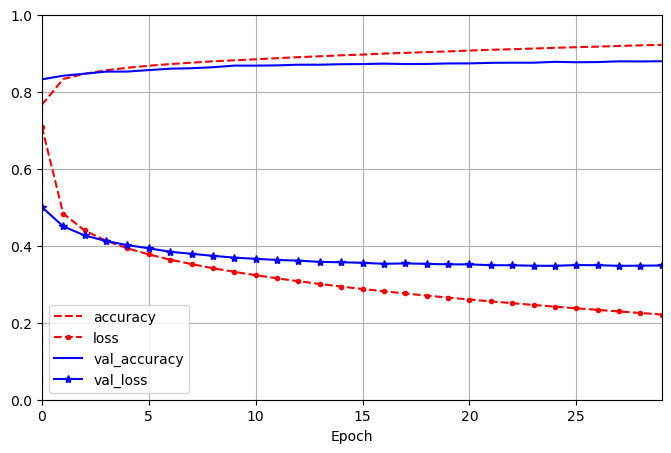

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(
figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [25]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8778 - loss: 0.3676


[0.362737238407135, 0.8773999810218811]

In [26]:
X_new = X_test[:3]

In [27]:
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.21, 0.  , 0.02, 0.  , 0.77],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [28]:
import numpy as np
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])

In [29]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [30]:
y_new = y_test[:3]

In [31]:
y_new

array([9, 2, 1], dtype=uint8)

# COMPLEX MODEL

In [32]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input_], outputs=[output])

In [33]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 28, 28)    │         57 │ input_layer_2[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 28, 30)    │        870 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 28, 30)    │        930 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 58)    │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 28, 1)     │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,916 (7.49 KB)

 Trainable params: 1,859 (7.26 KB)

 Non-trainable params: 57 (232.00 B)

In [34]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
normalization_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - RootMeanSquaredError: 3.2175 - loss: 10.5220 - val_RootMeanSquaredError: 2.9115 - val_loss: 8.4770
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8875 - loss: 8.3378 - val_RootMeanSquaredError: 2.9001 - val_loss: 8.4105
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8794 - loss: 8.2908 - val_RootMeanSquaredError: 2.8958 - val_loss: 8.3858
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8765 - loss: 8.2745 - val_RootMeanSquaredError: 2.8944 - val_loss: 8.3773
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - RootMeanSquaredError: 2.8752 - loss: 8.2670 - val_RootMeanSquaredError: 2.8937 - val_loss: 8.3735
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - RootMeanSquaredError: 2.8744 - loss: 8.2623 - val_RootMeanSquaredError: 2.8934 - val_loss: 8.3719
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredErro

What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [35]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [36]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# Flatten the images and select the correct columns for wide and deep inputs
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Wide: features 0 to 4 (each feature is a column in the original image)
X_train_wide = X_train_flat[:, :5]
X_valid_wide = X_valid_flat[:, :5]
X_test_wide = X_test_flat[:, :5]
X_new_wide = X_test_wide[:3]

# Deep: features 2 to 7
X_train_deep = X_train_flat[:, 2:8]
X_valid_deep = X_valid_flat[:, 2:8]
X_test_deep = X_test_flat[:, 2:8]
X_new_deep = X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - RootMeanSquaredError: 3.2939 - loss: 11.1367 - val_RootMeanSquaredError: 2.7989 - val_loss: 7.8337
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.7791 - loss: 7.7236 - val_RootMeanSquaredError: 2.7895 - val_loss: 7.7813
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.7680 - loss: 7.6619 - val_RootMeanSquaredError: 2.7809 - val_loss: 7.7335
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.7609 - loss: 7.6224 - val_RootMeanSquaredError: 2.7735 - val_loss: 7.6922
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.7572 - loss: 7.6020 - val_RootMeanSquaredError: 2.7686 - val_loss: 7.6651
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredError: 2.7532 - loss: 7.5802 - val_RootMeanSquaredError: 2.7680 - val_loss: 7.6618
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - RootMeanSquaredErro

In [37]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

Adding an auxiliary output for regularization::

In [38]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output, aux_output])

In [39]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer,
                metrics=["RootMeanSquaredError", "RootMeanSquaredError"])

In [40]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - dense_2_RootMeanSquaredError: 3.4178 - dense_2_loss: 12.0127 - dense_3_RootMeanSquaredError: 3.6015 - dense_3_loss: 13.3871 - loss: 12.1501 - val_dense_2_RootMeanSquaredError: 2.8138 - val_dense_2_loss: 7.9171 - val_dense_3_RootMeanSquaredError: 2.8076 - val_dense_3_loss: 7.8817 - val_loss: 7.9141
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - dense_2_RootMeanSquaredError: 2.7897 - dense_2_loss: 7.7825 - dense_3_RootMeanSquaredError: 2.7830 - dense_3_loss: 7.7455 - loss: 7.7788 - val_dense_2_RootMeanSquaredError: 2.8080 - val_dense_2_loss: 7.8846 - val_dense_3_RootMeanSquaredError: 2.7976 - val_dense_3_loss: 7.8262 - val_loss: 7.8789
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - dense_2_RootMeanSquaredError: 2.7761 - dense_2_loss: 7.7071 - dense_3_RootMeanSquaredError: 2.7735 - dense_3_loss: 7.6922 - loss: 7.7056 - val_dense_2_RootMeanSquaredError: 2.8050 - val_dense_2_loss: 7.8683 - val_dense_3_RootMeanSquaredE

In [41]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_2_RootMeanSquaredError: 2.7363 - dense_2_loss: 7.4878 - dense_3_RootMeanSquaredError: 2.7416 - dense_3_loss: 7.5169 - loss: 7.4907


In [42]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


In [43]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model.output_names, y_pred_tuple))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


## Using the Subclassing API to Build Dynamic Models

In [44]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)
        
    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

tf.random.set_seed(42)  # extra code – just for reproducibility
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

In [45]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=optimizer,
                metrics=["RootMeanSquaredError", "RootMeanSquaredError"])
model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - RootMeanSquaredError: 3.3553 - RootMeanSquaredError_1: 3.4248 - loss: 11.6180 - mse_loss: 12.0568 - val_RootMeanSquaredError: 2.8036 - val_RootMeanSquaredError_1: 2.8073 - val_loss: 7.8624 - val_mse_loss: 7.8800
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7849 - RootMeanSquaredError_1: 2.7920 - loss: 7.7598 - mse_loss: 7.7955 - val_RootMeanSquaredError: 2.7898 - val_RootMeanSquaredError_1: 2.7917 - val_loss: 7.7840 - val_mse_loss: 7.7936
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7716 - RootMeanSquaredError_1: 2.7745 - loss: 7.6834 - mse_loss: 7.6980 - val_RootMeanSquaredError: 2.7810 - val_RootMeanSquaredError_1: 2.7831 - val_loss: 7.7349 - val_mse_loss: 7.7462
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7649 - RootMeanSquaredError_1: 2.7653 - loss: 7.6450 - mse_loss: 7.6470 - val_RootMeanSquaredError: 2.7746 - val_RootMea

# Saving & Exporting Data

In [46]:
# extra code – delete the directory, in case it already exists

import shutil

shutil.rmtree("my_keras_model", ignore_errors=True)

In [47]:
model.export("my_keras_model")

INFO:tensorflow:Assets written to: my_keras_model\assets


INFO:tensorflow:Assets written to: my_keras_model\assets


Saved artifact at 'my_keras_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Tuple[TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)]
Output Type:
  Tuple[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2221088246864: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2221088256272: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2221088249168: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2221088248016: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2221088254160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2221088259344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2221123518736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2221123519504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2221123521616: TensorSpec(shape=(), dtype=tf.resou

In [48]:
tfsm_layer = tf.keras.layers.TFSMLayer("my_keras_model")
y_pred_main, y_pred_aux = tfsm_layer((X_new_wide, X_new_deep))

In [49]:
model.save_weights("my_weights.weights.h5")

In [50]:
model.load_weights("my_weights.weights.h5")

In [51]:
model.save("my_model.keras")

In [52]:
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

In [53]:
shutil.rmtree("my_checkpoints", ignore_errors=True)  # extra code

In [54]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpoints.weights.h5",
                                                    save_weights_only=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb])

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7502 - RootMeanSquaredError_1: 2.7514 - loss: 7.5645 - mse_loss: 7.5700 - val_RootMeanSquaredError: 2.7621 - val_RootMeanSquaredError_1: 2.7615 - val_loss: 7.6288 - val_mse_loss: 7.6277
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7497 - RootMeanSquaredError_1: 2.7508 - loss: 7.5614 - mse_loss: 7.5670 - val_RootMeanSquaredError: 2.7618 - val_RootMeanSquaredError_1: 2.7614 - val_loss: 7.6271 - val_mse_loss: 7.6272
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7494 - RootMeanSquaredError_1: 2.7503 - loss: 7.5599 - mse_loss: 7.5642 - val_RootMeanSquaredError: 2.7616 - val_RootMeanSquaredError_1: 2.7617 - val_loss: 7.6263 - val_mse_loss: 7.6288
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7491 - RootMeanSquaredError_1: 2.7500 - loss: 7.5580 - mse_loss: 7.5624 - val_RootMeanSquaredError: 2.7613 - val_RootMeanS

In [55]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                        restore_best_weights=True)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=100,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.7473 - RootMeanSquaredError_1: 2.7476 - loss: 7.5479 - mse_loss: 7.5493 - val_RootMeanSquaredError: 2.7600 - val_RootMeanSquaredError_1: 2.7594 - val_loss: 7.6174 - val_mse_loss: 7.6163
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7470 - RootMeanSquaredError_1: 2.7473 - loss: 7.5461 - mse_loss: 7.5478 - val_RootMeanSquaredError: 2.7596 - val_RootMeanSquaredError_1: 2.7591 - val_loss: 7.6152 - val_mse_loss: 7.6145
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - RootMeanSquaredError: 2.7468 - RootMeanSquaredError_1: 2.7470 - loss: 7.5450 - mse_loss: 7.5462 - val_RootMeanSquaredError: 2.7592 - val_RootMeanSquaredError_1: 2.7587 - val_loss: 7.6129 - val_mse_loss: 7.6124
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.7465 - RootMeanSquaredError_1: 2.7467 - loss: 7.5434 - mse_loss: 7.5443 - val_RootMeanSquaredError: 2.7593 - val_RootM

In [56]:
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [57]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[val_train_ratio_cb], verbose=0)

Epoch=0, val/train=1.01
Epoch=1, val/train=1.01
Epoch=2, val/train=1.01
Epoch=3, val/train=1.01
Epoch=4, val/train=1.01
Epoch=5, val/train=1.01
Epoch=6, val/train=1.01
Epoch=7, val/train=1.01
Epoch=8, val/train=1.01
Epoch=9, val/train=1.01


In [107]:

%pip install -q -U tensorboard-plugin-profile

Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'tensorboard-plugin-profile' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'tensorboard-plugin-profile'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'xprof' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'xprof'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [58]:
shutil.rmtree("my_logs", ignore_errors=True)

In [59]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

In [60]:
# extra code – builds the first regression model we used earlier
tf.keras.backend.clear_session()
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)

c:\Users\uzebk\miniconda3\envs\dsenv\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard_cb])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - RootMeanSquaredError: 3.2016 - loss: 10.3491 - val_RootMeanSquaredError: 2.9259 - val_loss: 8.5611
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - RootMeanSquaredError: 2.8985 - loss: 8.4017 - val_RootMeanSquaredError: 2.9106 - val_loss: 8.4715
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - RootMeanSquaredError: 2.8863 - loss: 8.3309 - val_RootMeanSquaredError: 2.9050 - val_loss: 8.4389
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - RootMeanSquaredError: 2.8814 - loss: 8.3025 - val_RootMeanSquaredError: 2.9019 - val_loss: 8.4213
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - RootMeanSquaredError: 2.8787 - loss: 8.2868 - val_RootMeanSquaredError: 2.9000 - val_loss: 8.4102
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - RootMeanSquaredError: 2.8769 - loss: 8.2767 - val_RootMeanSquaredError: 2.8987 - val_loss: 8.4025
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - RootMeanSquaredErro

In [62]:
print("my_logs")
for path in sorted(Path("my_logs").glob("**/*")):
    print("  " * (len(path.parts) - 1) + path.parts[-1])

my_logs
  run_2025_10_23_18_39_16
    train
      events.out.tfevents.1761224987.UZEB.2072.0.v2
      plugins
        profile
          2025_10_23_13_09_49
            UZEB.xplane.pb
    validation
      events.out.tfevents.1761224994.UZEB.2072.1.v2


In [65]:
# extra code

from IPython.display import display, HTML

display(HTML('<a href="http://localhost:6006/">http://localhost:6006/</a>'))

In [66]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(str(test_logdir))
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100  # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        images = np.random.rand(2, 32, 32, 3) * step / 1000  # gets brighter
        tf.summary.image("my_images", images, step=step)
        
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)
        
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

In [67]:
# extra code – lists all running TensorBoard server instances

from tensorboard import notebook

notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ./my_logs (started 0:02:22 ago; pid 22384)


In [69]:
!taskkill /F /PID 22384

SUCCESS: The process with PID 22384 has been terminated.


## Hyperparameter Tuning

In [70]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [71]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [72]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                                sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                    metrics=["accuracy"])
    return model

In [73]:
random_search_tuner = kt.RandomSearch(
build_model, objective="val_accuracy", max_trials=5, overwrite=True,
directory="my_fashion_mnist", project_name="my_rnd_search", seed=42)
random_search_tuner.search(X_train, y_train, epochs=10,
validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 43s]
val_accuracy: 0.8309999704360962

Best val_accuracy So Far: 0.8579999804496765
Total elapsed time: 00h 03m 44s


In [74]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [75]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values 

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [76]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8579999804496765


In [77]:
best_trial.metrics.get_last_value("val_accuracy")

np.float64(0.8579999804496765)

In [78]:
best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8725 - loss: 0.3437
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8784 - loss: 0.3289
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8815 - loss: 0.3190
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3097
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8882 - loss: 0.3019
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8897 - loss: 0.2940
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8926 - loss: 0.2872
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8967 - loss: 0.2798
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8984 - loss: 0.2736
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9008 - loss: 0.2683
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8584 - loss: 0.4126


In [79]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            norm_layer.adapt(X)
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

In [80]:
hyperband_tuner = kt.Hyperband(
MyClassificationHyperModel(), objective="val_accuracy", seed=42,
max_epochs=10, factor=3, hyperband_iterations=2,
overwrite=True, directory="my_fashion_mnist", project_name="hyperband")

In [ ]:
root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)
hyperband_tuner.search(X_train, y_train, epochs=10,
validation_data=(X_valid, y_valid),
callbacks=[early_stopping_cb, tensorboard_cb])

In [ ]:
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(), objective="val_accuracy", seed=42,
    max_trials=10, alpha=1e-4, beta=2.6,
    overwrite=True, directory="my_fashion_mnist", project_name="bayesian_opt")
bayesian_opt_tuner.search(X_train, y_train, epochs=10,
                            validation_data=(X_valid, y_valid),
                            callbacks=[early_stopping_cb])

In [ ]:
%tensorboard --logdir {root_logdir}